In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "svg.fonttype": "none",
})

# Purple theme colors from seaborn - discretized to 10 colors
PURPLE_PALETTE = sns.color_palette("Purples", n_colors=10)

# Colors for the three distributions
GT_COLOR = "maroon"           # Ground truth
PROPOSAL_COLOR = PURPLE_PALETTE[5]    # Proposal distribution
RESAMPLED_COLOR = PURPLE_PALETTE[8]   # Resampled distribution

In [20]:
DATA_BASE = Path(
    "/home/mila/d/danyal.rehman/scratch/transferable-samplers/transferable-samplers/sequential-boltzmann-generators-data/sequential-boltzmann-generators-data"
)

SYSTEMS = {
    "ALDP": {
        "display_name": "ALDP (Ace-A-Nme)",
        "pdb_path": DATA_BASE / "Ace-A-Nme_300K" / "Ace-A-Nme_300K.pdb",
        "test_data_path": DATA_BASE / "Ace-A-Nme_300K" / "Ace-A-Nme_300K_test.npy",
        "train_data_path": DATA_BASE / "Ace-A-Nme_300K" / "Ace-A-Nme_300K_train.npy",
        "samples_pt_path": Path("data/ALDP_samples.pt"),  # PLACEHOLDER
        "n_atoms": 22,
        "temperature": 300,
        "xlim": (-60, 40),
        "ylim": (0, 0.1),
    },
    "AL3": {
        "display_name": "AL3 (AAA)",
        "pdb_path": DATA_BASE / "AAA_310K" / "AAA_310K.pdb",
        "test_data_path": DATA_BASE / "AAA_310K" / "AAA_310K_test.npy",
        "train_data_path": DATA_BASE / "AAA_310K" / "AAA_310K_train.npy",
        "samples_pt_path": Path("data/AL3_samples.pt"),  # PLACEHOLDER
        "n_atoms": 33,
        "temperature": 310,
        "xlim": (-225, -50),
        "ylim": (0, 0.08),
    },
    "AL4": {
        "display_name": "AL4 (Ace-AAA-Nme)",
        "pdb_path": DATA_BASE / "Ace-AAA-Nme_300K" / "Ace-AAA-Nme_300K.pdb",
        "test_data_path": DATA_BASE / "Ace-AAA-Nme_300K" / "Ace-AAA-Nme_300K_test.npy",
        "train_data_path": DATA_BASE / "Ace-AAA-Nme_300K" / "Ace-AAA-Nme_300K_train.npy",
        "samples_pt_path": Path("data/AL4_samples.pt"),  # PLACEHOLDER
        "n_atoms": 42,
        "temperature": 300,
        "xlim": (-50, 100),
        "ylim": (0, 0.06),
    },
    "AL6": {
        "display_name": "AL6 (AAAAAA)",
        "pdb_path": DATA_BASE / "AAAAAA_310K" / "AAAAAA_310K.pdb",
        "test_data_path": DATA_BASE / "AAAAAA_310K" / "AAAAAA_310K_test.npy",
        "train_data_path": DATA_BASE / "AAAAAA_310K" / "AAAAAA_310K_train.npy",
        "samples_pt_path": Path("data/AL6_samples.pt"),  # PLACEHOLDER
        "n_atoms": 66,
        "temperature": 310,
        "xlim": (-150, 0),
        "ylim": (0, 0.05),
    },
    "Chignolin": {
        "display_name": "Chignolin (GYDPETGTWG)",
        "pdb_path": DATA_BASE / "GYDPETGTWG_310K" / "GYDPETGTWG_310K.pdb",
        "test_data_path": DATA_BASE / "GYDPETGTWG_310K" / "GYDPETGTWG_310K_test.npy",
        "train_data_path": DATA_BASE / "GYDPETGTWG_310K" / "GYDPETGTWG_310K_train.npy",
        "samples_pt_path": Path("data/Chignolin_samples.pt"),  # PLACEHOLDER
        "n_atoms": 138,
        "temperature": 310,
        "xlim": (-500, -250),
        "ylim": (0, 0.05),
    },
}

# Order for plotting
SYSTEM_ORDER = ["ALDP", "AL3", "AL4", "AL6", "Chignolin"]

# --- Resampling settings ---
MAX_SAMPLES = 200000
CLIP_QUANTILE = 0.002
RESAMPLE_N = None

# --- Energy settings ---
ENERGY_DEVICE = "cuda"

# --- Plot settings ---
NUM_BINS = 150

In [4]:
def apply_in_ticks(ax):
    """Apply inward-pointing tick marks with length=6 to all sides."""
    ax.tick_params(direction="in", length=6, top=True, right=True, left=True, bottom=True)


def load_samples_dict(pt_path: Path) -> dict:
    """Load samples dictionary from .pt file."""
    d = torch.load(pt_path, map_location="cpu", weights_only=False)
    required = {"prior_samples", "proposal_samples", "proposal_log_q"}
    if not required.issubset(d):
        raise ValueError(f"{pt_path} missing keys {required - set(d)}")
    return d


def coerce_to_xyz(samples, n_atoms):
    """Convert samples to (N, n_atoms, 3) shape."""
    if isinstance(samples, torch.Tensor):
        samples = samples.cpu().numpy()
    samples = np.asarray(samples)

    if samples.ndim == 3:
        return samples
    if samples.ndim == 2:
        return samples.reshape(-1, n_atoms, 3)

    raise ValueError("Unrecognized sample shape")


def compute_std_from_training_data(path: Path) -> float:
    """Compute standard deviation of training data for position scaling."""
    x = np.load(path)
    x = x - x.mean(axis=1, keepdims=True)
    return float(x.std())

In [5]:
def compute_importance_log_weights(log_q, energies_kT, clip_quantile=None):
    """Compute importance weights for resampling."""
    log_w = -energies_kT - log_q

    if clip_quantile is None:
        return log_w, np.ones(len(log_w), bool)

    cutoff = np.quantile(log_w, 1.0 - clip_quantile)
    mask = log_w <= cutoff
    return log_w[mask], mask


def resample_with_importance_weights(samples_xyz, log_w, n_samples=None, seed=0):
    """Resample using importance weights."""
    g = torch.Generator().manual_seed(seed)
    probs = torch.softmax(torch.tensor(log_w), dim=0)

    if n_samples is None:
        n_samples = len(samples_xyz)

    idx = torch.multinomial(probs, n_samples, replacement=True, generator=g)
    return samples_xyz[idx.numpy()]

In [6]:
def make_openmm_energy_fn(pdb_path: Path, temperature: int, device="cuda"):
    """Create an OpenMM energy function for the given molecule."""
    import openmm
    import openmm.app
    import openmm.unit

    pdb = openmm.app.PDBFile(str(pdb_path))
    forcefield = openmm.app.ForceField(
        "amber99sbildn.xml", "tip3p.xml", "amber99_obc.xml"
    )

    system = forcefield.createSystem(
        pdb.topology,
        nonbondedMethod=openmm.app.NoCutoff,
        constraints=None,
    )

    integrator = openmm.LangevinMiddleIntegrator(
        temperature * openmm.unit.kelvin,
        1.0 / openmm.unit.picosecond,
        1.0 * openmm.unit.femtosecond,
    )

    platform = openmm.Platform.getPlatformByName("CUDA" if device == "cuda" else "CPU")
    context = openmm.Context(system, integrator, platform)

    kT = (openmm.unit.MOLAR_GAS_CONSTANT_R * temperature * openmm.unit.kelvin).value_in_unit(
        openmm.unit.kilojoule_per_mole
    )

    def energy_fn(x_nm):
        E = np.empty(len(x_nm))
        for i, x in enumerate(x_nm):
            context.setPositions(x * openmm.unit.nanometer)
            state = context.getState(getEnergy=True)
            E[i] = state.getPotentialEnergy().value_in_unit(
                openmm.unit.kilojoule_per_mole
            ) / kT
        return E

    return energy_fn

In [7]:
def load_system_energies(system_config, seed=0):
    """
    Load all energy distributions for a single system.
    
    Returns:
        dict with keys: 'gt_energies', 'proposal_energies', 'resampled_energies'
    """
    pdb_path = system_config["pdb_path"]
    test_data_path = system_config["test_data_path"]
    train_data_path = system_config["train_data_path"]
    samples_pt_path = system_config["samples_pt_path"]
    n_atoms = system_config["n_atoms"]
    temperature = system_config["temperature"]
    
    # Compute position scale from training data
    try:
        position_scale = compute_std_from_training_data(train_data_path)
    except FileNotFoundError:
        position_scale = 0.162962  # Default fallback
    
    # Create energy function
    energy_fn = make_openmm_energy_fn(pdb_path, temperature, ENERGY_DEVICE)
    
    # --- Load Ground Truth ---
    print(f"  Loading ground truth from {test_data_path}...")
    test_samples = np.load(test_data_path)
    if MAX_SAMPLES and len(test_samples) > MAX_SAMPLES:
        idx = np.random.default_rng(seed).choice(len(test_samples), MAX_SAMPLES, replace=False)
        test_samples = test_samples[idx]
    gt_energies = energy_fn(test_samples.astype(np.float32))
    
    # --- Load Proposal and Compute Resampled ---
    print(f"  Loading proposal samples from {samples_pt_path}...")
    d = load_samples_dict(samples_pt_path)
    xyz = coerce_to_xyz(d["proposal_samples"], n_atoms)
    log_q = d["proposal_log_q"].cpu().numpy()
    
    if MAX_SAMPLES and len(xyz) > MAX_SAMPLES:
        idx = np.random.default_rng(seed + 1).choice(len(xyz), MAX_SAMPLES, replace=False)
        xyz, log_q = xyz[idx], log_q[idx]
    
    # Compute energies on proposal samples (unnormalized, in nm)
    print(f"  Computing proposal energies...")
    proposal_energies = energy_fn((xyz * position_scale).astype(np.float32))
    
    # Compute importance weights and resample
    print(f"  Computing resampled energies...")
    log_w, mask = compute_importance_log_weights(log_q, proposal_energies, CLIP_QUANTILE)
    resampled_xyz = resample_with_importance_weights(xyz[mask], log_w, RESAMPLE_N, seed + 2)
    resampled_energies = energy_fn((resampled_xyz * position_scale).astype(np.float32))
    
    return {
        "gt_energies": gt_energies,
        "proposal_energies": proposal_energies,
        "resampled_energies": resampled_energies,
    }

In [8]:
# Load energy distributions for all systems
all_system_data = {}

for i, sys_name in enumerate(SYSTEM_ORDER):
    print(f"\nLoading {sys_name}...")
    config = SYSTEMS[sys_name]
    all_system_data[sys_name] = load_system_energies(config, seed=i * 10)
    print(f"  Done! GT: {len(all_system_data[sys_name]['gt_energies'])}, "
          f"Proposal: {len(all_system_data[sys_name]['proposal_energies'])}, "
          f"Resampled: {len(all_system_data[sys_name]['resampled_energies'])}")

print("\nAll systems loaded successfully!")


Loading ALDP...
  Loading ground truth from /home/mila/d/danyal.rehman/scratch/transferable-samplers/transferable-samplers/sequential-boltzmann-generators-data/sequential-boltzmann-generators-data/Ace-A-Nme_300K/Ace-A-Nme_300K_test.npy...
  Loading proposal samples from data/ALDP_samples.pt...
  Computing proposal energies...
  Computing resampled energies...
  Done! GT: 200000, Proposal: 200000, Resampled: 199600

Loading AL3...
  Loading ground truth from /home/mila/d/danyal.rehman/scratch/transferable-samplers/transferable-samplers/sequential-boltzmann-generators-data/sequential-boltzmann-generators-data/AAA_310K/AAA_310K_test.npy...
  Loading proposal samples from data/AL3_samples.pt...
  Computing proposal energies...
  Computing resampled energies...
  Done! GT: 180000, Proposal: 200000, Resampled: 199600

Loading AL4...
  Loading ground truth from /home/mila/d/danyal.rehman/scratch/transferable-samplers/transferable-samplers/sequential-boltzmann-generators-data/sequential-boltz

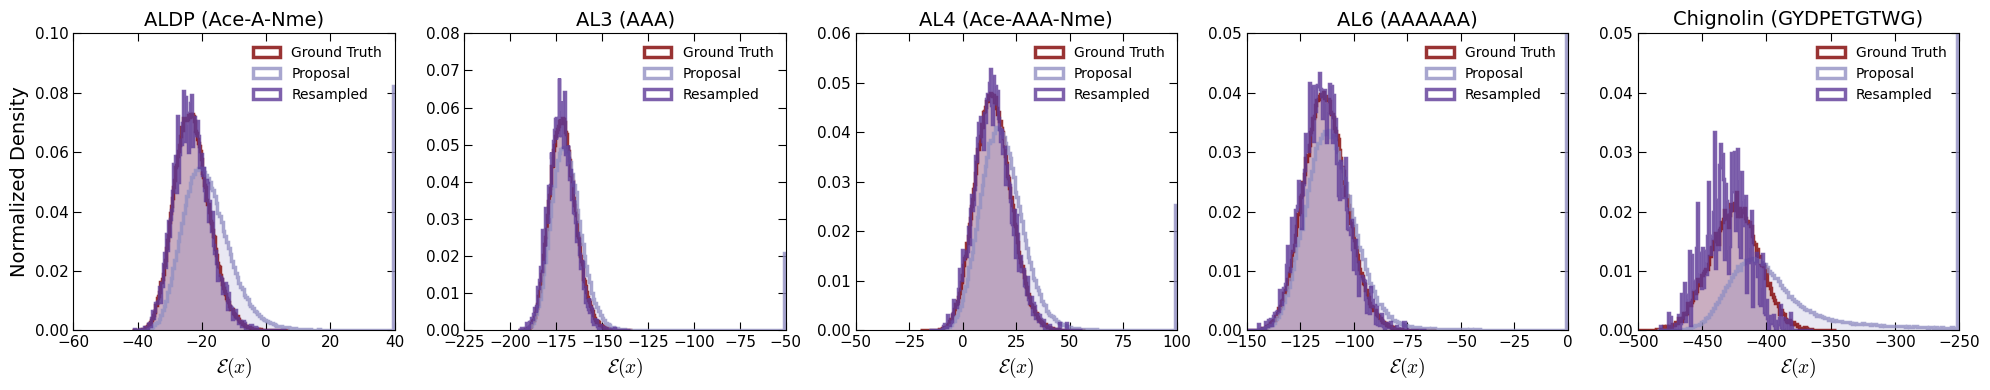

In [21]:
def plot_filled_hist(ax, data, bins, color, label, linewidth=2.5, fill_alpha=0.2):
    """Plot histogram with filled area and step outline."""
    ax.hist(data, bins=bins, density=True, alpha=fill_alpha, color=color, histtype="stepfilled")
    ax.hist(data, bins=bins, density=True, alpha=0.8, color=color, histtype="step", 
            linewidth=linewidth, label=label)


# Create 1x5 figure
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for idx, sys_name in enumerate(SYSTEM_ORDER):
    ax = axes[idx]
    config = SYSTEMS[sys_name]
    data = all_system_data[sys_name]
    
    # Get energies
    gt_energies = data["gt_energies"]
    proposal_energies = data["proposal_energies"]
    resampled_energies = data["resampled_energies"]
    
    # Get xlim from config
    x_min, x_max = config["xlim"]
    y_min, y_max = config["ylim"]
    
    # Crop function to handle outliers
    energy_cropper = lambda x, xmin=x_min, xmax=x_max: np.clip(x, a_min=xmin + 0.1, a_max=xmax - 0.1)
    
    # Plot histograms
    plot_filled_hist(ax, energy_cropper(gt_energies), NUM_BINS, GT_COLOR, "Ground Truth")
    plot_filled_hist(ax, energy_cropper(proposal_energies), NUM_BINS, PROPOSAL_COLOR, "Proposal")
    plot_filled_hist(ax, energy_cropper(resampled_energies), NUM_BINS, RESAMPLED_COLOR, "Resampled")
    
    # Set x-axis limits
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    # Labels and title
    ax.set_xlabel(r"$\mathcal{E}(x)$")
    ax.set_title(config["display_name"])
    
    if idx == 0:
        ax.set_ylabel("Normalized Density")
    
    apply_in_ticks(ax)
    axes[idx].legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.savefig("figures/multi_system_energy.pdf", bbox_inches="tight")
plt.show()